# Bitblind Attack Demo

This notebook serves as a demonstration for Bitblind OCR and ASR Evasion against the Google/Youtube models.

__OCR__: Optical Character Recognition, reading text off of the screen.
> We evade through our adversarially rendered subtitles.

__ASR__: Automatic Speech Recognition, pulling voice out of a video and converting it to parsable text.
> We evade through adversarial perturbations to the audio.

In [3]:
import sys
import os
import warnings

warnings.simplefilter("ignore", FutureWarning)

In [5]:
# Import our code to interact with the google vision API
from ocr.utils.google_vision import query_google_vision, predict_and_annotate

# Import all of our image processing code.
from ocr.utils.image_tools import show_image, render_subtitles, transcribe_to_subtitles, replace_audio, get_frame_at_time

In [27]:
# Define the input data.
INPUT_VIDEO = "demo_data/obama_test_video_short.mp4"
OUTPUT_FROM_ASR_ATTACK = "demo_data/asr_output.mp4"

# Define where to write output data.
OCR_OUTPUT = "demo_data/ocr_output.mp4"
FINAL_OUTPUT_VIDEO = "demo_data/final_output.mp4"

## Step 1: OCR Attack

We want to start by extracting the un-perturbed transcription, then rendering it over our input video.

In [11]:
# Generate ground truth subtitles with the OpenAI Whisper.
# Inputing the original video with original audio.
subtitles = transcribe_to_subtitles(INPUT_VIDEO, model_size="small", mode="segment")

# Removes apostrophes because the font does not play nice with them.
for line in subtitles:
    line['text'] = line['text'].replace("'", "")

subtitles

[{'text': 'Honestly, what they say doesnt bother me.',
  'start': 0.0,
  'end': 3.0},
 {'text': 'I understand weve got an adversarial system.',
  'start': 3.0,
  'end': 5.0},
 {'text': 'Im a mellow sort of guy.', 'start': 5.0, 'end': 7.0},
 {'text': 'And thats why I invited Luther...', 'start': 7.0, 'end': 10.0}]

In [12]:
# Here we define the text rendering parameters.
# We adversarially learned these in ocr/black_box_chars/text_attack.ipynb

params = {
            # Degrees of rotation per character
            'per_char_rot_std': 2.9505478000000003,

            # Space between individual letters
            'kerning_std': -8.2049265,

            # Text is rendered along a sine wave
            'baseline_amp': 2.8154181,
            'baseline_freq': 1.0,
            
            # Adds additionally y axis jitter to the wave rendering.
            'y_jitter_std': 4.504429200000001
         }

In [22]:
# Now time to render the subtitles.

render_subtitles(
    video_path=INPUT_VIDEO,
    output_path=OCR_OUTPUT,
    subtitles=subtitles,
    font_size=40,
    max_chars=30,
    font_path='ocr/resources/fonts/zxx-noise.ttf',
    params=params
)

Saved to demo_data/ocr_output.mp4 (313 frames at 30.00 fps)


# Step 2: Combine with ASR Attack

This attack is from [Watch What You Pretrain For: Targeted, Transferable Adversarial Examples on Self-Supervised Speech Recognition models](rxiv.org/abs/2209.13523).

Using `asr/asr_transferability`, we generated `demo_data/asr_output.mp4`, which adds a noise layer to the audio to evade automatic speech recognition.

In [29]:
# Outputs demo_data/final_output.mp4

replace_audio(source_video=OCR_OUTPUT,
              audio_video=OUTPUT_FROM_ASR_ATTACK,
              output_path=FINAL_OUTPUT_VIDEO)

# Step 3: Evaluation

Now we want to see how effective our video is at evading data scraping.

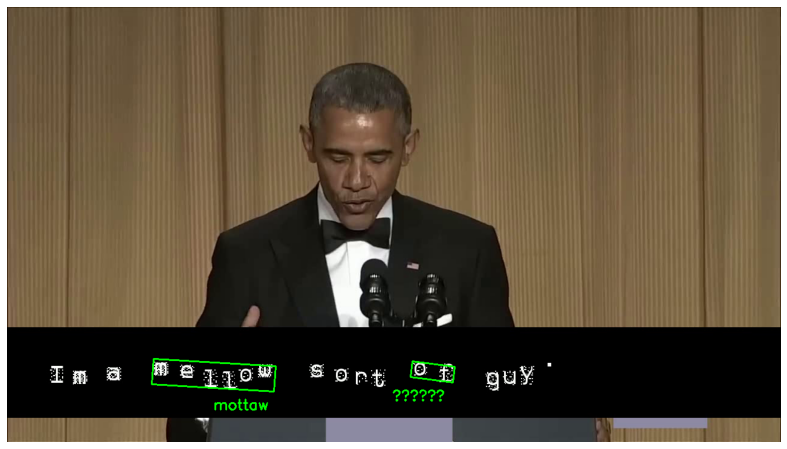

In [39]:
# Start with checking the OCR output.

# Get a sample frame from each of the four "lines" in the video.
f1 = get_frame_at_time(FINAL_OUTPUT_VIDEO, t=2)
f2 = get_frame_at_time(FINAL_OUTPUT_VIDEO, t=4)
f3 = get_frame_at_time(FINAL_OUTPUT_VIDEO, t=6)
f4 = get_frame_at_time(FINAL_OUTPUT_VIDEO, t=8)

frames = [f1, f2, f3, f4]
show_image(predict_and_annotate(f3))

In [49]:
# Print out the true text against what OCR extracted.

print("------------------------------------------------------------------")

for i, f in enumerate(frames):
    print(f"TRUE TEXT: {subtitles[i]['text']}")
    print(fr"OCR TEXT: {repr(query_google_vision(f)['text'])}")
    print("------------------------------------------------------------------")

------------------------------------------------------------------
TRUE TEXT: Honestly, what they say doesnt bother me.
OCR TEXT: 'Honestly, what they\nbothe\ndoesnt'
------------------------------------------------------------------
TRUE TEXT: I understand weve got an adversarial system.
OCR TEXT: 'puetsua pun I\nStand\ndversarial\n7 o b\n· F S A\nD A D M\nan'
------------------------------------------------------------------
TRUE TEXT: Im a mellow sort of guy.
OCR TEXT: '蛋糕\nmottaw'
------------------------------------------------------------------
TRUE TEXT: And thats why I invited Luther...
OCR TEXT: 'And thats why\nLuther'
------------------------------------------------------------------


In [50]:
# Now we can show the ASR evasion through the youtube interface.
# Below is the demo video. Open it and turn on Subtitles/Closed Captioning.

"""
https://www.youtube.com/watch?v=OzFY_uet3E8
"""

# Below is a transcription of what youtube outputs

yt_output = [
    "And honestly, what could they say about their bobly",
    "brother",
    "from the mellow throat of Browning",
    "And thats why I invited Luther"
]


print("------------------------------------------------------------------")

for i, f in enumerate(yt_output):
    print(f"TRUE TEXT: {subtitles[i]['text']}")
    print(fr"ASR TEXT: {f}")
    print("------------------------------------------------------------------")

------------------------------------------------------------------
TRUE TEXT: Honestly, what they say doesnt bother me.
ASR TEXT: And honestly, what could they say about their bobly
------------------------------------------------------------------
TRUE TEXT: I understand weve got an adversarial system.
ASR TEXT: brother
------------------------------------------------------------------
TRUE TEXT: Im a mellow sort of guy.
ASR TEXT: from the mellow throat of Browning
------------------------------------------------------------------
TRUE TEXT: And thats why I invited Luther...
ASR TEXT: And thats why I invited Luther
------------------------------------------------------------------


## Conclusion

Long story short, attacking large black box models is very, very hard.

OCR evasion works very well, and doesn't significantly degrade the user experience (it could be prettied up a little).

ASR evasion on the other hand, does not work nearly as well. The ASR transferrability attack is pretty limited by the proxy models you are able to run on your hardware. I was using an RTX 3090 to run the models: `hubert-large-960h`, `wav2vec2-large-960h-lv60-self`, and `conformer-mini-101`. These models are trained on 100s of hours of audio (960h in the model name -> 960 hours of training audio), but Google's Universal Speech Model (USM) is trained on 12 million hours of audio. This discrepancy means that the attack budget had to be quite high to change the USM output, which makes the perturbation loud, degrading the user experience.

In this current state, the OCR evading subtitles are usable in the real world since they are easy to render (once the parameters are learned), and don't hurt video utility. This ASR evasion is not useful from a practical perspective due to how loud it has to be.
